# Question 5: Gaussian Filtering

- **(a)** Compute a normalized 5×5 Gaussian kernel for σ = 2 using NumPy
- **(b)** Visualize a 51×51 Gaussian kernel as a 3D surface plot
- **(c)** Apply Gaussian smoothing using the manually computed kernel
- **(d)** Apply Gaussian smoothing using `cv.GaussianBlur()` and compare

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
%matplotlib inline

## (a) Compute a Normalized 5×5 Gaussian Kernel (σ = 2)

The 2D Gaussian function is:

$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

For a 5×5 kernel, x and y range from -2 to 2. After computing the kernel values, we **normalize** by dividing by the sum so all coefficients add up to 1 — this ensures the filtered image has the same overall brightness.

5×5 Gaussian Kernel (σ=2):
[[0.0232 0.0338 0.0383 0.0338 0.0232]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0383 0.0558 0.0632 0.0558 0.0383]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0232 0.0338 0.0383 0.0338 0.0232]]

Kernel sum (should be 1.0): 1.000000
Kernel shape: (5, 5)


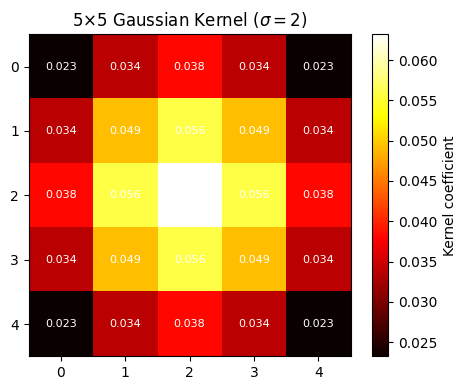

In [2]:
def gaussian_kernel(size, sigma):
    """
    Compute a normalized 2D Gaussian kernel using NumPy.

    Parameters
    ----------
    size  : int   - kernel size (must be odd, e.g. 5, 51)
    sigma : float - standard deviation of the Gaussian

    Returns
    -------
    kernel : np.ndarray of shape (size, size), normalized to sum to 1
    """
    # Create coordinate grids centered at 0
    half = size // 2
    x = np.arange(-half, half + 1)          # e.g. [-2, -1, 0, 1, 2] for size=5
    y = np.arange(-half, half + 1)
    X, Y = np.meshgrid(x, y)

    # Compute Gaussian values
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

    # Normalize so coefficients sum to 1
    kernel = kernel / kernel.sum()

    return kernel


# Compute the 5x5 kernel with sigma=2
sigma = 2
kernel_5x5 = gaussian_kernel(size=5, sigma=sigma)

print(f'5×5 Gaussian Kernel (σ={sigma}):')
print(np.array2string(kernel_5x5, precision=4, suppress_small=True))
print(f'\nKernel sum (should be 1.0): {kernel_5x5.sum():.6f}')
print(f'Kernel shape: {kernel_5x5.shape}')

# Visualise the 5x5 kernel as a heatmap
plt.figure(figsize=(5, 4))
plt.imshow(kernel_5x5, cmap='hot', interpolation='nearest')
plt.colorbar(label='Kernel coefficient')
plt.title(rf'5×5 Gaussian Kernel ($\sigma={sigma}$)')
for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{kernel_5x5[i, j]:.3f}', ha='center', va='center',
                 fontsize=8, color='white')
plt.tight_layout()
plt.savefig('output/q5a_kernel_5x5.png', dpi=150, bbox_inches='tight')
plt.show()

## (b) Visualize a 51×51 Gaussian Kernel as a 3D Surface Plot

A larger kernel (51×51) gives a smoother surface that clearly shows the bell-curve shape of the Gaussian.

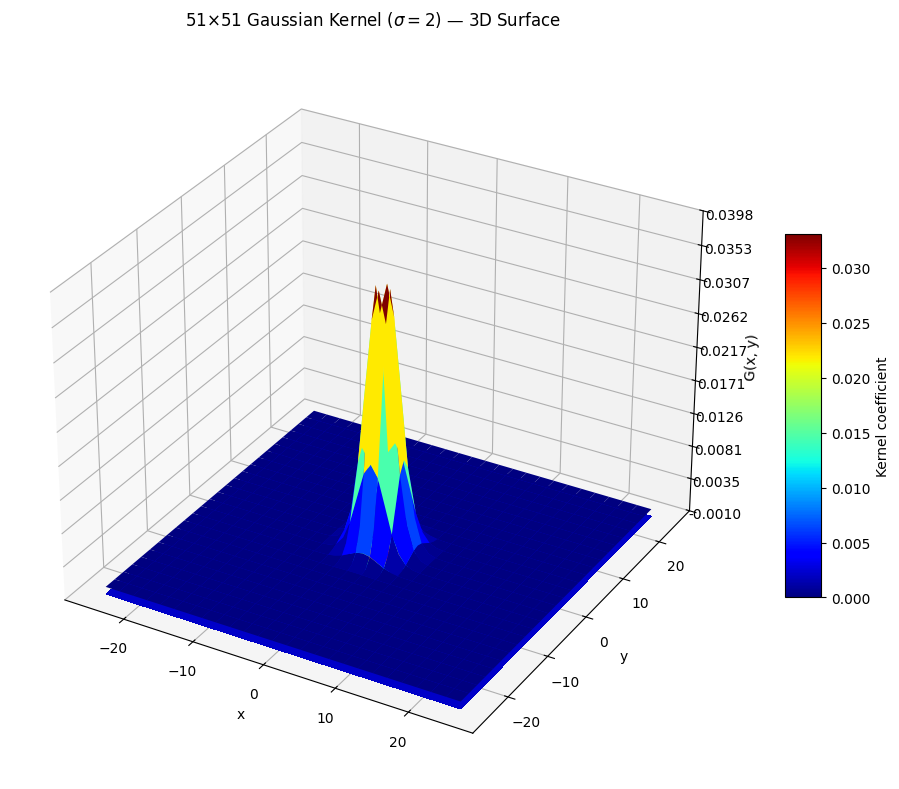

In [3]:
# Compute the 51x51 kernel
kernel_51x51 = gaussian_kernel(size=51, sigma=sigma)

# Create coordinate grids for plotting
half = 51 // 2
x = np.arange(-half, half + 1)
y = np.arange(-half, half + 1)
X, Y = np.meshgrid(x, y)

# 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, kernel_51x51, cmap=cm.jet,
                       linewidth=0, antialiased=True)

ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.4f'))

# Contour projection on the base
cset = ax.contourf(X, Y, kernel_51x51, zdir='z',
                   offset=kernel_51x51.min() - 0.001, cmap=cm.jet)
ax.set_zlim(kernel_51x51.min() - 0.001, kernel_51x51.max())

fig.colorbar(surf, shrink=0.5, aspect=10, label='Kernel coefficient')
ax.set_title(rf'51×51 Gaussian Kernel ($\sigma={sigma}$) — 3D Surface', pad=20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('G(x, y)')

plt.tight_layout()
plt.savefig('output/q5b_kernel_51x51_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Load the Runway Image for Filtering

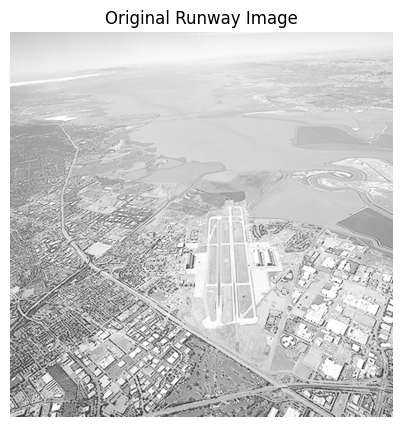

Image shape: (769, 765)


In [4]:
img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Could not load runway.png. Check the images/ folder."

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Runway Image')
plt.axis('off')
plt.show()
print('Image shape:', img.shape)

## (c) Apply Gaussian Smoothing Using the Manually Computed Kernel

We use `cv.filter2D()` to convolve the image with our manually built 5×5 kernel.

`cv.CV_32F` ensures the output is computed in floating point to avoid precision loss, then we clip back to uint8 for display.

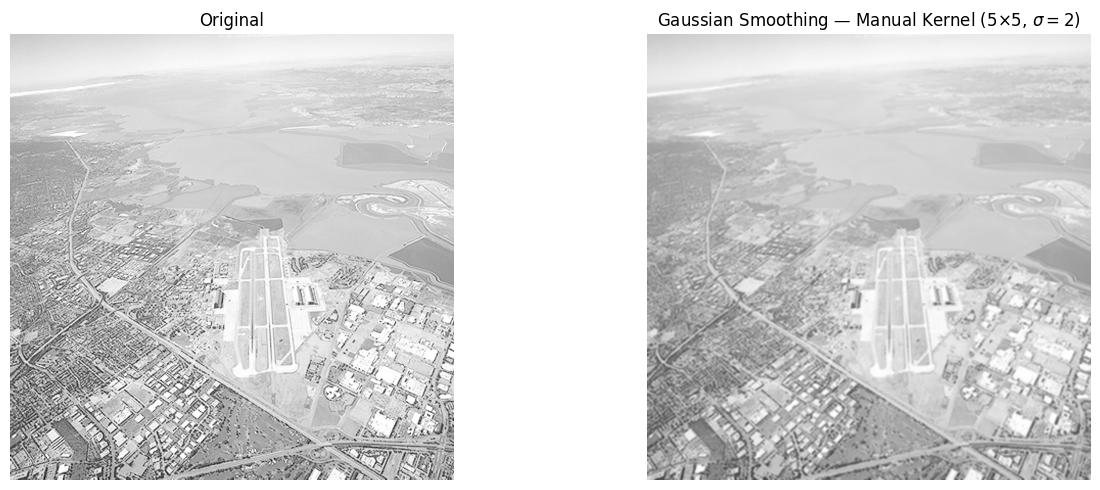

In [5]:
# Apply manual kernel using cv.filter2D
img_manual = cv.filter2D(img, cv.CV_32F, kernel_5x5.astype(np.float32))
img_manual = np.clip(img_manual, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(rf'Gaussian Smoothing — Manual Kernel (5×5, $\sigma={sigma}$)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q5c_manual_gaussian.png', dpi=150, bbox_inches='tight')
plt.show()

## (d) Apply Gaussian Smoothing Using `cv.GaussianBlur()`

`cv.GaussianBlur(src, ksize, sigmaX)` internally builds and applies a Gaussian kernel.
- `ksize` must be odd — we use `(5, 5)` to match our manual kernel
- `sigmaX=2` matches our σ = 2

The results should be **nearly identical** to the manual approach.

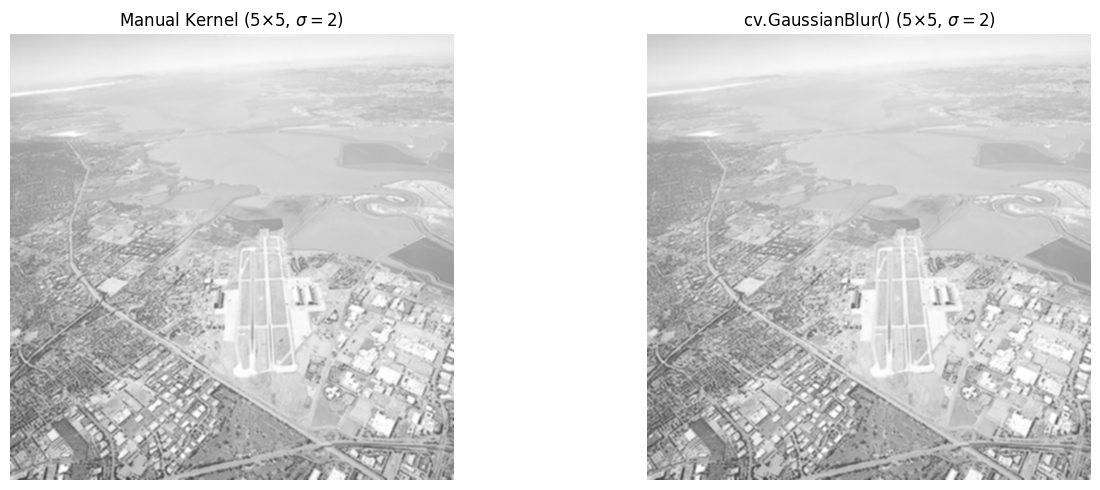

In [6]:
# Apply using OpenCV's built-in GaussianBlur
img_cv = cv.GaussianBlur(img, ksize=(5, 5), sigmaX=sigma, sigmaY=sigma)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_manual, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(rf'Manual Kernel (5×5, $\sigma={sigma}$)')
axes[0].axis('off')

axes[1].imshow(img_cv, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(rf'cv.GaussianBlur() (5×5, $\sigma={sigma}$)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q5d_opencv_gaussian.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare Manual vs OpenCV — Pixel Difference

Comparison — Manual kernel vs cv.GaussianBlur():
  Max pixel difference : 1
  Mean pixel difference: 0.4999


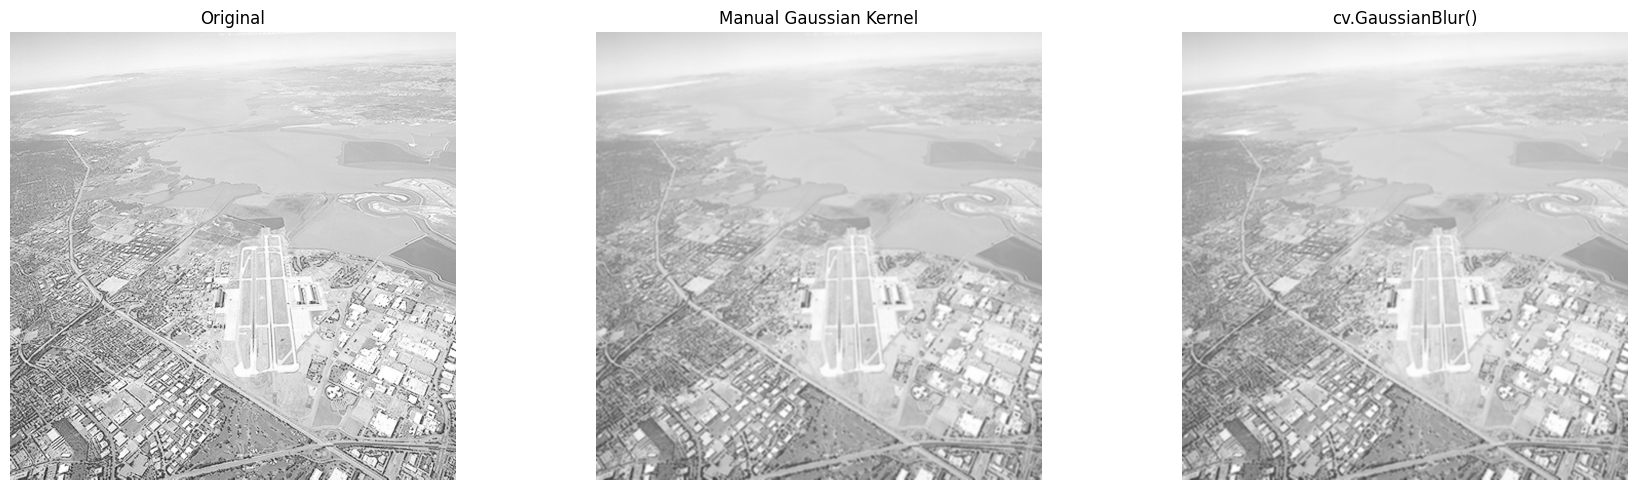


Note: Small differences (≤1) are due to rounding in floating-point arithmetic.
Both methods produce visually identical results.


In [7]:
diff = np.abs(img_manual.astype(int) - img_cv.astype(int))

print('Comparison — Manual kernel vs cv.GaussianBlur():')
print(f'  Max pixel difference : {diff.max()}')
print(f'  Mean pixel difference: {diff.mean():.4f}')

# Full summary — all 4 images side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Manual Gaussian Kernel')
axes[1].axis('off')

axes[2].imshow(img_cv, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('cv.GaussianBlur()')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/q5_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: Small differences (≤1) are due to rounding in floating-point arithmetic.')
print('Both methods produce visually identical results.')